## Example Notebook: Epoch-Wise Post-Hoc Reversal on CIFAR-N

This notebook reproduces the epoch-wise post-hoc reversal curves for CIFAR-N (Figure 1 in the paper), modulo styling.

Other datasets are similar, except that they don't have the `--noise` argument (they are naturally noisy).

### Experimental Runs

#### Setup

In [14]:
import os

import matplotlib.pyplot as plt
import pandas as pd

from expt.utils import KeyValStore

# "cifar10", "cifar100_coarse", or "cifar100_fine"
os.environ["DATASET"] = "cifar10"

# "clean", "aggregate", "random1", "random2", "random3", or "worst" for cifar10
# "clean" or "noisy" for cifar100_coarse and cifar100_fine
os.environ["NOISE"] = "worst"

# number of models to train for ensembling
os.environ["ENSEMBLE_SIZE"] = "8"

# name of wandb project
# use "''" to skip wandb logging
# os.environ["WANDB"] = "post-hoc-reversal"
os.environ["WANDB"] = "''"

Running for the first time downloads and prepares the data.

In [15]:
%%bash
python -m expt.cifar --root out/dummy --wandb '' --dataset $DATASET --noise $NOISE --num-epochs 0

args=Namespace(root='out/dummy', wandb='', dataset='cifar10', noise='worst', eval_batch_size=1000, train_batch_size=500, model='resnet18d', pretrained=True, width=64, optimizer='sgd', lr=0.1, momentum=0.9, weight_decay=0.0005, scheduler='cosine', num_epochs=0, amp=True, loss='ce', sop_lr_u=10.0, sop_lr_v=100.0, elr_momentum=0.9, elr_weight=1.0)
num_classes=10
len(X['train'])=40000
len(X['val'])=5000
len(X['test'])=5000
max class freq: 0.12105999886989594
min class freq: 0.08079999685287476


#### Base (no transform) and SWA

Train `$ENSEMBLE_SIZE` models in parallel with default hyperparameters.  
Use `python -m expt.cifar --help` for options.

This assumes `$ENSEMBLE_SIZE` GPUs are available.  
For CPU-only environments, use `export CUDA_VISIBLE_DEVICES=''`.  
For single-GPU environments, use `export CUDA_VISIBLE_DEVICES=0`.  
For sequential execution, e.g. to prevent memory issues on a single GPU, remove the `&`.

On a _Quadro RTX 8000_ GPU, each run takes around 3 minutes.

This records the Base (no transform) and SWA checkpoints for every epoch.

In [17]:
%%bash
for i in $(seq 1 $ENSEMBLE_SIZE)
do
    export CUDA_VISIBLE_DEVICES=$((i-1))
    # python -m expt.cifar --root out/idv$i --wandb $WANDB --dataset $DATASET --noise $NOISE &
    python -m expt.cifar --root out/idv$i --dataset $DATASET --noise $NOISE &
done
wait

args=Namespace(root='out/idv7', wandb='2023-08-23', dataset='cifar10', noise='worst', eval_batch_size=1000, train_batch_size=500, model='resnet18d', pretrained=True, width=64, optimizer='sgd', lr=0.1, momentum=0.9, weight_decay=0.0005, scheduler='cosine', num_epochs=100, amp=True, loss='ce', sop_lr_u=10.0, sop_lr_v=100.0, elr_momentum=0.9, elr_weight=1.0)
num_classes=10
len(X['train'])=40000
len(X['val'])=5000
len(X['test'])=5000
max class freq: 0.12105999886989594
min class freq: 0.08079999685287476
run.name='cifar10__worst__idv7'
args=Namespace(root='out/idv1', wandb='2023-08-23', dataset='cifar10', noise='worst', eval_batch_size=1000, train_batch_size=500, model='resnet18d', pretrained=True, width=64, optimizer='sgd', lr=0.1, momentum=0.9, weight_decay=0.0005, scheduler='cosine', num_epochs=100, amp=True, loss='ce', sop_lr_u=10.0, sop_lr_v=100.0, elr_momentum=0.9, elr_weight=1.0)
num_classes=10
len(X['train'])=40000
len(X['val'])=5000
len(X['test'])=5000
max class freq: 0.1210599988

#### Temperature Scaling

Now we calibrate (temperature-scale) the Base and SWA checkpoints for every epoch. On a _Quadro RTX 8000_ GPU this takes around 20s.

In [18]:
%%bash
for i in $(seq 1 $ENSEMBLE_SIZE)
do
    export CUDA_VISIBLE_DEVICES=$((i-1))
    python -m expt.calibrate --root out/idv$i --wandb $WANDB --base base &
    python -m expt.calibrate --root out/idv$i --wandb $WANDB --base base+swa &
done
wait

args=Namespace(root='out/idv8', wandb="''", base='base', cal='temp_scaler', suf='ts')
args=Namespace(root='out/idv4', wandb="''", base='base+swa', cal='temp_scaler', suf='ts')
args=Namespace(root='out/idv5', wandb="''", base='base+swa', cal='temp_scaler', suf='ts')
args=Namespace(root='out/idv3', wandb="''", base='base', cal='temp_scaler', suf='ts')
args=Namespace(root='out/idv5', wandb="''", base='base', cal='temp_scaler', suf='ts')
args=Namespace(root='out/idv7', wandb="''", base='base+swa', cal='temp_scaler', suf='ts')
args=Namespace(root='out/idv8', wandb="''", base='base+swa', cal='temp_scaler', suf='ts')
args=Namespace(root='out/idv4', wandb="''", base='base', cal='temp_scaler', suf='ts')
args=Namespace(root='out/idv6', wandb="''", base='base', cal='temp_scaler', suf='ts')
args=Namespace(root='out/idv1', wandb="''", base='base+swa', cal='temp_scaler', suf='ts')
args=Namespace(root='out/idv6', wandb="''", base='base+swa', cal='temp_scaler', suf='ts')
args=Namespace(root='out/idv2'

epochs:  74%|██████████████████████████████▎          | 74/100 [00:14<00:05,  4.91it/s]

wandb: 🚀 View run base+ts__idv8 at: https://wandb.ai/rishabh-ranjan/''/runs/hy8jzowd
wandb: Find logs at: ../../../../../../afs/cs.stanford.edu/u/ranjanr/.cache/wandb/run-20240928_171714-hy8jzowd/logs
wandb: 🚀 View run base+swa+ts__idv8 at: https://wandb.ai/rishabh-ranjan/''/runs/edojbhhe
wandb: Find logs at: ../../../../../../afs/cs.stanford.edu/u/ranjanr/.cache/wandb/run-20240928_171718-edojbhhe/logs
wandb: 🚀 View run base+swa+ts__idv7 at: https://wandb.ai/rishabh-ranjan/''/runs/tnrtsubb
wandb: Find logs at: ../../../../../../afs/cs.stanford.edu/u/ranjanr/.cache/wandb/run-20240928_171718-tnrtsubb/logs
wandb: 🚀 View run base+swa+ts__idv5 at: https://wandb.ai/rishabh-ranjan/''/runs/uxjptqcz
wandb: Find logs at: ../../../../../../afs/cs.stanford.edu/u/ranjanr/.cache/wandb/run-20240928_171717-uxjptqcz/logs
wandb: 🚀 View run base+ts__idv3 at: https://wandb.ai/rishabh-ranjan/''/runs/1c75ilrn
wandb: Find logs at: ../../../../../../afs/cs.stanford.edu/u/ranjanr/.cache/wandb/run-20240928_1717

#### Ensembling

Next, we ensemble the base models and all compositions of post-hoc transforms we have so far, per epoch. On a _Quadro RTX 8000_ GPU this takes around 20s. Note that _"ensemble"_ in the paper actually refers to `ts+ens` in the code.

In [19]:
%%bash
for s in val test train_true train_false
do
    for b in base base+swa base+ts base+swa+ts
    do
        python -m expt.ensemble --root out/ens$ENSEMBLE_SIZE --wandb $WANDB --runs out/idv* --split $s --base $b &
    done
done
wait

args=Namespace(root='out/ens8', wandb="''", runs=['out/idv1', 'out/idv2', 'out/idv3', 'out/idv4', 'out/idv5', 'out/idv6', 'out/idv7', 'out/idv8'], split='test', base='base+swa')
args=Namespace(root='out/ens8', wandb="''", runs=['out/idv1', 'out/idv2', 'out/idv3', 'out/idv4', 'out/idv5', 'out/idv6', 'out/idv7', 'out/idv8'], split='test', base='base+swa+ts')
args=Namespace(root='out/ens8', wandb="''", runs=['out/idv1', 'out/idv2', 'out/idv3', 'out/idv4', 'out/idv5', 'out/idv6', 'out/idv7', 'out/idv8'], split='val', base='base+ts')
args=Namespace(root='out/ens8', wandb="''", runs=['out/idv1', 'out/idv2', 'out/idv3', 'out/idv4', 'out/idv5', 'out/idv6', 'out/idv7', 'out/idv8'], split='val', base='base')
args=Namespace(root='out/ens8', wandb="''", runs=['out/idv1', 'out/idv2', 'out/idv3', 'out/idv4', 'out/idv5', 'out/idv6', 'out/idv7', 'out/idv8'], split='train_true', base='base')
args=Namespace(root='out/ens8', wandb="''", runs=['out/idv1', 'out/idv2', 'out/idv3', 'out/idv4', 'out/idv5', 'o

epochs:  29%|███████████▉                             | 29/100 [00:11<00:22,  3.21it/s]

wandb: 🚀 View run base+swa+ts+ens__ens8 at: https://wandb.ai/rishabh-ranjan/''/runs/0bxw59y1
wandb: Find logs at: ../../../../../../afs/cs.stanford.edu/u/ranjanr/.cache/wandb/run-20240928_171750-0bxw59y1/logs


epochs:  58%|███████████████████████▊                 | 58/100 [00:20<00:10,  4.17it/s]

wandb: 🚀 View run base+swa+ens__ens8 at: https://wandb.ai/rishabh-ranjan/''/runs/ou5v20zf
wandb: Find logs at: ../../../../../../afs/cs.stanford.edu/u/ranjanr/.cache/wandb/run-20240928_171750-ou5v20zf/logs
wandb: 🚀 View run base+ts+ens__ens8 at: https://wandb.ai/rishabh-ranjan/''/runs/t45ceel1
wandb: Find logs at: ../../../../../../afs/cs.stanford.edu/u/ranjanr/.cache/wandb/run-20240928_171750-t45ceel1/logs
wandb: 🚀 View run base+swa+ts+ens__ens8 at: https://wandb.ai/rishabh-ranjan/''/runs/lvgqx2pv
wandb: Find logs at: ../../../../../../afs/cs.stanford.edu/u/ranjanr/.cache/wandb/run-20240928_171755-lvgqx2pv/logs
wandb: 🚀 View run base+ens__ens8 at: https://wandb.ai/rishabh-ranjan/''/runs/5l24bmyf
wandb: Find logs at: ../../../../../../afs/cs.stanford.edu/u/ranjanr/.cache/wandb/run-20240928_171750-5l24bmyf/logs
wandb: 🚀 View run base+ts+ens__ens8 at: https://wandb.ai/rishabh-ranjan/''/runs/vkies9rl
wandb: Find logs at: ../../../../../../afs/cs.stanford.edu/u/ranjanr/.cache/wandb/run-202

epochs:  99%|████████████████████████████████████████▌| 99/100 [00:27<00:00,  6.15it/s]

wandb: 🚀 View run base+ts+ens__ens8 at: https://wandb.ai/rishabh-ranjan/''/runs/sxhxytft
wandb: Find logs at: ../../../../../../afs/cs.stanford.edu/u/ranjanr/.cache/wandb/run-20240928_171753-sxhxytft/logs
wandb: 🚀 View run base+ens__ens8 at: https://wandb.ai/rishabh-ranjan/''/runs/kjrziybq
wandb: Find logs at: ../../../../../../afs/cs.stanford.edu/u/ranjanr/.cache/wandb/run-20240928_171755-kjrziybq/logs
wandb: 🚀 View run base+ens__ens8 at: https://wandb.ai/rishabh-ranjan/''/runs/5mokw0ux
wandb: Find logs at: ../../../../../../afs/cs.stanford.edu/u/ranjanr/.cache/wandb/run-20240928_171755-5mokw0ux/logs
wandb: 🚀 View run base+swa+ts+ens__ens8 at: https://wandb.ai/rishabh-ranjan/''/runs/cuqivvmt
wandb: Find logs at: ../../../../../../afs/cs.stanford.edu/u/ranjanr/.cache/wandb/run-20240928_171755-cuqivvmt/logs
wandb: 🚀 View run base+swa+ts+ens__ens8 at: https://wandb.ai/rishabh-ranjan/''/runs/xbqtc77q
wandb: Find logs at: ../../../../../../afs/cs.stanford.edu/u/ranjanr/.cache/wandb/run-202

Finally, we calibrate the ensembles (again, for every epoch). On a _Quadro RTX 8000_ GPU this takes around 20s.

In [20]:
%%bash
for b in base+ens base+swa+ens base+ts+ens base+swa+ts+ens
do
    # python -m expt.calibrate --root out/ens$ENSEMBLE_SIZE --wandb $WANDB --base $b &
    python -m expt.calibrate --root out/ens$ENSEMBLE_SIZE --base $b &
done
wait

args=Namespace(root='out/ens8', wandb='2023-07-28', base='base+ts+ens', cal='temp_scaler', suf='ts')
args=Namespace(root='out/ens8', wandb='2023-07-28', base='base+swa+ts+ens', cal='temp_scaler', suf='ts')
args=Namespace(root='out/ens8', wandb='2023-07-28', base='base+ens', cal='temp_scaler', suf='ts')
args=Namespace(root='out/ens8', wandb='2023-07-28', base='base+swa+ens', cal='temp_scaler', suf='ts')
wandb: 🚀 View run base+ens+ts__ens8 at: https://wandb.ai/rishabh-ranjan/2023-07-28/runs/4gqn2k2t
wandb: Find logs at: ../../../../../../afs/cs.stanford.edu/u/ranjanr/.cache/wandb/run-20240928_171838-4gqn2k2t/logs
wandb: 🚀 View run base+ts+ens+ts__ens8 at: https://wandb.ai/rishabh-ranjan/2023-07-28/runs/ua97ps6r
wandb: Find logs at: ../../../../../../afs/cs.stanford.edu/u/ranjanr/.cache/wandb/run-20240928_171837-ua97ps6r/logs
wandb: 🚀 View run base+swa+ts+ens+ts__ens8 at: https://wandb.ai/rishabh-ranjan/2023-07-28/runs/fybrp1dz
wandb: Find logs at: ../../../../../../afs/cs.stanford.edu/u/

### Plots for Post-Hoc Reversal

In [21]:
import seaborn as sns

sns.set_theme(context="paper", style="whitegrid", font_scale=0.75)
plt.rcParams["figure.dpi"] = 157
plt.rcParams["xtick.major.size"] = 0
plt.rcParams["ytick.major.size"] = 0

LINE = 5.5

from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from pathlib import Path

def save_fig(fig, save_key):
    path = f"figures/{save_key}.pdf"
    Path(path).parent.mkdir(exist_ok=True, parents=True)
    fig.savefig(path, bbox_inches="tight", pad_inches=0.01)
    print(f"saved at {path}")

In [22]:
def make_fig(kv):
    fig, axs = plt.subplots(
        2, 1, figsize=(0.5 * LINE, 0.5 * LINE), height_ratios=[2, 1], sharex=True,
        layout="constrained"
    )

    scale = 100

    x = kv.load("epochs")

    ax = axs[0]

    split = "train_true"

    Y = kv.load(f"err/{split}/base") * scale
    # for y in Y:
    #     ax.plot(x, y, color="tab:blue", alpha=0.2)
    y = Y.mean(0)
    ax.plot(x, y, color="tab:blue")

    Y = kv.load(f"err/{split}/base+swa") * scale
    # for y in Y:
    #     ax.plot(x, y, color="tab:cyan", alpha=0.2)
    y = Y.mean(0)
    ax.plot(x, y, color="tab:blue", ls="--")

    split = "train_false"

    Y = kv.load(f"err/{split}/base") * scale
    # for y in Y:
    #     ax.plot(x, y, color="tab:red", alpha=0.2)
    y = Y.mean(0)
    ax.plot(x, y, color="tab:red")

    Y = kv.load(f"err/{split}/base+swa") * scale
    # for y in Y:
    #     ax.plot(x, y, color="tab:orange", alpha=0.2)
    y = Y.mean(0)
    ax.plot(x, y, color="tab:red", ls="--")

    ax.axvline(8, color="tab:gray", lw=1, ls=":")
    ax.text(4, 55, "Base model\noverfits", rotation=90, verticalalignment='center')

    ax.axvline(40, color="tab:gray", lw=1, ls=":")
    ax.text(36, 34, "SWA\noverfits", rotation=90, verticalalignment='center')

    ax.set_ylabel("Train error (%)")
    # ax.legend()
    ax.grid()
    # ax.set_xlabel("Epochs")

    ax.legend(
        handles=[
            Patch(facecolor="tab:blue", label="Clean subset"),
            Patch(facecolor="tab:red", label="Mislabeled subset"),
            Line2D([0], [0], color="black", ls="solid", label="Base"),
            Line2D([0], [0], color="black", ls="dashed", label="SWA"),
        ],
        loc="upper right",
    )
    ax.set_title("CIFAR-10-N Worst")

    ###############################################
    ax = axs[1]

    split = "test"

    Y = kv.load(f"err/{split}/base") * scale
    # for y in Y:
    #     ax.plot(x, y, color="tab:red", alpha=0.2)
    y = Y.mean(0)
    ax.plot(x, y, color="tab:purple")

    Y = kv.load(f"err/{split}/base+swa") * scale
    # for y in Y:
    #     ax.plot(x, y, color="tab:orange", alpha=0.2)
    y = Y.mean(0)
    ax.plot(x, y, color="tab:purple", ls="--")
    
    ax.axvline(8, color="tab:gray", lw=1, ls=":")
    ax.axvline(40, color="tab:gray", lw=1, ls=":")

    ax.set_xlim(0, 100)
    ax.set_xlabel("Epochs")
    ax.set_ylabel("Test error (%)")
    ax.grid()
    
    ax.legend(
        handles=[
            Patch(facecolor="tab:purple", label="Test set"),
            Line2D([0], [0], color="black", ls="solid", label="Base"),
            Line2D([0], [0], color="black", ls="dashed", label="SWA"),
        ],
        loc="upper right"
    )

    # fig.legend(
    #     handles=[
    #         # Patch(facecolor="tab:blue", label="Clean train subset"),
    #         # Patch(facecolor="tab:red", label="Noisy train subset"),
    #         # Patch(facecolor="tab:purple", label="Full test set"),
    #         # Patch(alpha=0),
    #         Line2D([0], [0], color="black", ls="solid", label="Base"),
    #         Line2D([0], [0], color="black", ls="dashed", label="SWA"),
    #     ],
    #     ncol=2,
    #     loc="upper center",
    #     bbox_to_anchor=(0.5, 0),
    # )

    return fig

saved at figures/intuition_memorization.pdf


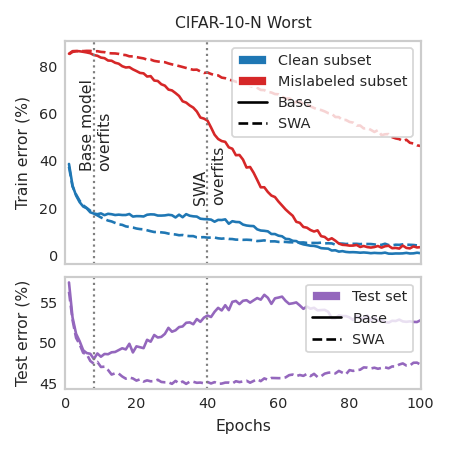

In [23]:
kv = KeyValStore(f"out/ens{os.environ['ENSEMBLE_SIZE']}")
fig = make_fig(kv)
save_fig(fig, "intuition_memorization")

In [37]:
def make_fig(kv):
    fig, ax = plt.subplots(
        1, 1, figsize=(0.5 * LINE, 0.3 * LINE), layout="constrained"
    )

    scale = 100

    x = kv.load("epochs")

    Y = kv.load(f"osc/train_true/base") * scale
    for y in Y:
        ax.plot(x, y, color="tab:blue", alpha=0.2)
    y = Y.mean(0)
    ax.plot(x, y, color="tab:blue")

    Y = kv.load(f"osc/train_false/base") * scale
    for y in Y:
        ax.plot(x, y, color="tab:red", alpha=0.2)
    y = Y.mean(0)
    ax.plot(x, y, color="tab:red")
    
    # Y = kv.load(f"osc/test/base") * scale
    # for y in Y:
    #     ax.plot(x, y, color="tab:purple", alpha=0.2)
    # y = Y.mean(0)
    # ax.plot(x, y, color="tab:purple")
    
    ax.legend(
        handles=[
            Patch(facecolor="tab:blue", label="Clean subset"),
            Patch(facecolor="tab:red", label="Mislabeled subset"),
        ],
        loc="upper right",
    )
    ax.set_title("CIFAR-10-N Worst")

    ax.set_xlabel("Epochs")
    ax.set_ylabel("% of predictions flipped")
    ax.set_xlim(0, 100)
    ax.set_ylim(bottom=0)

    return fig

saved at figures/intuition_oscillation.pdf


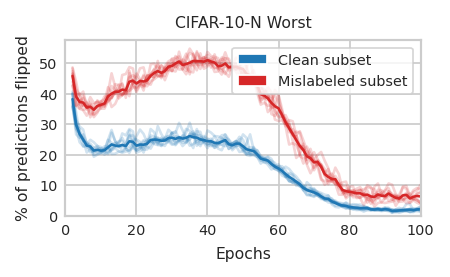

In [38]:
kv = KeyValStore(f"out/ens{os.environ['ENSEMBLE_SIZE']}")
fig = make_fig(kv)
save_fig(fig, "intuition_oscillation")

In [39]:
def make_fig(kv):
    fig, ax = plt.subplots(
        1, 1, figsize=(0.5 * LINE, 0.2 * LINE), layout="constrained"
    )

    scale = 1

    x = kv.load("epochs")

    Y = kv.load(f"temp/val/base") * scale
    for y in Y:
        ax.plot(x, y, color="tab:orange", alpha=0.2)
    y = Y.mean(0)
    ax.plot(x, y, color="tab:orange")

    ax.set_title("CIFAR-10-N Worst")

    ax.set_xlabel("Epochs")
    ax.set_ylabel("Optimal\nTemperature")
    ax.set_ylim(bottom=1)

    return fig

saved at figures/intuition_temperature.pdf


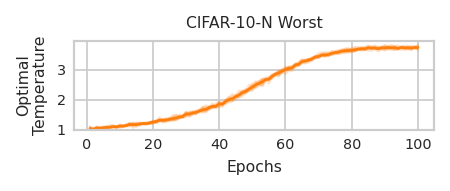

In [40]:
kv = KeyValStore(f"out/ens{os.environ['ENSEMBLE_SIZE']}")
fig = make_fig(kv)
save_fig(fig, "intuition_temperature")

### Table for Post-Hoc Selection

In [15]:
%%bash
python -m expt.select --root out/ens$ENSEMBLE_SIZE

args=Namespace(root='out/ens4', bases=['base', 'base+swa', 'base+ts', 'base+swa+ts', 'base+ens', 'base+swa+ens', 'base+ts+ens', 'base+swa+ts+ens', 'base+ens+ts', 'base+swa+ens+ts', 'base+ts+ens+ts', 'base+swa+ts+ens+ts'])


In [9]:
kv = KeyValStore(f"out/ens{os.environ['ENSEMBLE_SIZE']}")

Here we reproduce the post-hoc selection vs naive selection results from Table 1 in the paper. When possible, we show mean +- std.

In [14]:
txt = {
    "nll": "Test Loss",
    "err": "Test Error (%)",
    "base": "No Transform",
    "base+swa+ts": "SWA+TS",
    "base+swa+ts+ens+ts": "SWA+Ens+TS",
    "pre": "Naive",
    "post": "Ours",
}

In [21]:
rec = {}
for metric in ["nll", "err"]:
    scale = 100 if metric == "err" else 1
    fmt = ".2f" if metric == "err" else ".3f"

    for tr in ["base", "base+swa+ts", "base+swa+ts+ens+ts"]:
        for sel in ["pre", "post"]:
            key = (txt[metric], txt[tr], txt[sel])
            kv_key = f"sel={sel}/obj={metric}/{metric}/test/{tr}"
            kv_val = kv.load(kv_key).float() * scale
            if "ens" in tr:
                val = f"{kv_val.item():{fmt}}"
            else:
                val = f"{kv_val.mean().item():{fmt}}$\\pm${kv_val.std().item():{fmt}}"
            rec[key] = [val]
pd.DataFrame(rec)

Test Loss                                                     \
      No Transform                            SWA+TS                    
             Naive             Ours            Naive             Ours   
0  1.508$\pm$0.015  1.508$\pm$0.015  1.489$\pm$0.012  1.445$\pm$0.006   

                     Test Error (%)                                  \
  SWA+Ens+TS           No Transform                          SWA+TS   
       Naive   Ours           Naive            Ours           Naive   
0      1.450  1.407  46.98$\pm$0.80  46.98$\pm$0.80  46.46$\pm$0.88   

                                     
                  SWA+Ens+TS         
             Ours      Naive   Ours  
0  44.15$\pm$0.15      44.98  43.16